In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

supervised models results

In [2]:
supervised_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "KNN",
        "Linear SVM",
        "Logistic Regression"
    ],
    "Zero-Day Detection (%)": [
        56.91,
        50.03,
        40.77,
        37.01,
        36.40
    ],
    "Status": [
        "Optimized",
        "Optimized",
        "Baseline",
        "Baseline",
        "Baseline"
    ]
})

supervised_results

,Model,Zero-Day Detection (%),Status
0,Random Forest,56.91,Optimized
1,Decision Tree,50.03,Optimized
2,KNN,40.77,Baseline
3,Linear SVM,37.01,Baseline
4,Logistic Regression,36.40,Baseline


Unsupervised models results

In [3]:
unsupervised_results = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "One-Class SVM",
        "Local Outlier Factor"
    ],
    "Target FPR (%)": [
        5.0,
        5.0,
        5.0
    ],
    "Seen F1 (%)": [
        78.223383,
        77.190713,
        84.280173
    ],
    "Seen FPR (%)": [
        2.461127,
        4.242611,
        10.925754
    ],
    "Zero-Day Detection (%)": [
        65.280000,
        43.520000,
        26.693333
    ]
})

unsupervised_results

,Model,Target FPR (%),Seen F1 (%),Seen FPR (%),Zero-Day Detection (%)
0,Isolation Forest,5.0,78.223383,2.461127,65.280000
1,One-Class SVM,5.0,77.190713,4.242611,43.520000
2,Local Outlier Factor,5.0,84.280173,10.925754,26.693333


In [ ]:
Supervised models results comparison

In [4]:
supervised_comparison = supervised_results.sort_values(
    by="Zero-Day Detection (%)",
    ascending=False
).reset_index(drop=True)

supervised_comparison

,Model,Zero-Day Detection (%),Status
0,Random Forest,56.91,Optimized
1,Decision Tree,50.03,Optimized
2,KNN,40.77,Baseline
3,Linear SVM,37.01,Baseline
4,Logistic Regression,36.40,Baseline


In [ ]:
Unsupervised results based on fpr 

In [5]:
unsupervised_operating_points = pd.DataFrame([
    ["Isolation Forest", 1.0, 74.736053, 1.153331, 44.720000],
    ["Isolation Forest", 3.0, 77.005631, 2.059520, 57.973333],
    ["Isolation Forest", 5.0, 78.223383, 2.461127, 65.280000],
    ["Isolation Forest", 10.0, 79.815951, 7.331892, 72.400000],

    ["One-Class SVM", 1.0, 4.850427, 0.514880, 6.373333],
    ["One-Class SVM", 3.0, 11.903561, 2.471424, 24.773333],
    ["One-Class SVM", 5.0, 77.190713, 4.242611, 43.520000],
    ["One-Class SVM", 10.0, 81.316649, 5.601895, 57.653333],

    ["Local Outlier Factor", 1.0, 75.943698, 6.302132, 12.080000],
    ["Local Outlier Factor", 3.0, 81.940573, 8.958913, 16.640000],
    ["Local Outlier Factor", 5.0, 84.280173, 10.925754, 26.693333],
    ["Local Outlier Factor", 10.0, 85.712738, 15.116878, 33.173333]
], columns=[
    "Model",
    "Target FPR (%)",
    "Seen F1 (%)",
    "Seen FPR (%)",
    "Zero-Day Detection (%)"
])

unsupervised_operating_points

,Model,Target FPR (%),Seen F1 (%),Seen FPR (%),Zero-Day Detection (%)
0,Isolation Forest,1.0,74.736053,1.153331,44.720000
1,Isolation Forest,3.0,77.005631,2.059520,57.973333
2,Isolation Forest,5.0,78.223383,2.461127,65.280000
3,Isolation Forest,10.0,79.815951,7.331892,72.400000
4,One-Class SVM,1.0,4.850427,0.514880,6.373333
5,One-Class SVM,3.0,11.903561,2.471424,24.773333
6,One-Class SVM,5.0,77.190713,4.242611,43.520000
7,One-Class SVM,10.0,81.316649,5.601895,57.653333
8,Local Outlier Factor,1.0,75.943698,6.302132,12.080000
9,Local Outlier Factor,3.0,81.940573,8.958913,16.640000


In [6]:
unsupervised_final = unsupervised_operating_points[
    unsupervised_operating_points["Target FPR (%)"] == 5.0
].copy()

unsupervised_final = unsupervised_final.sort_values(
    by="Zero-Day Detection (%)",
    ascending=False
).reset_index(drop=True)

unsupervised_final

,Model,Target FPR (%),Seen F1 (%),Seen FPR (%),Zero-Day Detection (%)
0,Isolation Forest,5.0,78.223383,2.461127,65.280000
1,One-Class SVM,5.0,77.190713,4.242611,43.520000
2,Local Outlier Factor,5.0,84.280173,10.925754,26.693333


In [7]:
final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "KNN",
        "Linear SVM",
        "Logistic Regression",
        "Isolation Forest",
        "One-Class SVM",
        "Local Outlier Factor"
    ],
    "Family": [
        "Supervised",
        "Supervised",
        "Supervised",
        "Supervised",
        "Supervised",
        "Unsupervised",
        "Unsupervised",
        "Unsupervised"
    ],
    "Zero-Day Detection (%)": [
        56.91,
        50.03,
        40.77,
        37.01,
        36.40,
        65.28,
        43.52,
        26.693333
    ]
})

final_comparison = final_comparison.sort_values(
    by="Zero-Day Detection (%)",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Family,Zero-Day Detection (%)
0,Isolation Forest,Unsupervised,65.280000
1,Random Forest,Supervised,56.910000
2,Decision Tree,Supervised,50.030000
3,One-Class SVM,Unsupervised,43.520000
4,KNN,Supervised,40.770000
5,Linear SVM,Supervised,37.010000
6,Logistic Regression,Supervised,36.400000
7,Local Outlier Factor,Unsupervised,26.693333


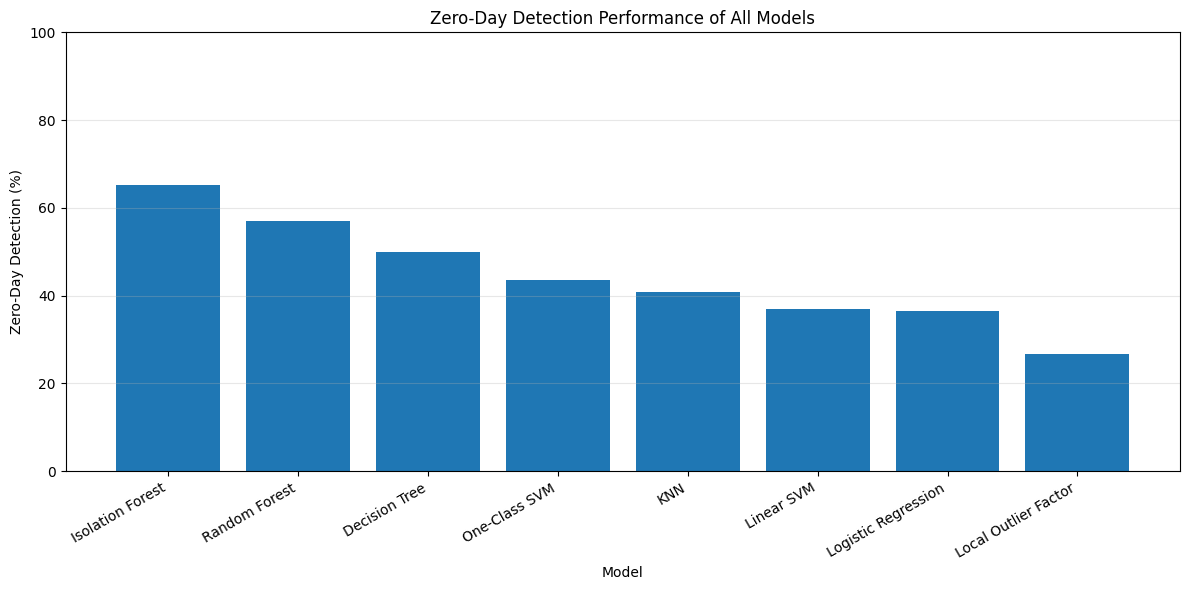

In [8]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["Zero-Day Detection (%)"]
)

plt.xlabel("Model")
plt.ylabel("Zero-Day Detection (%)")
plt.title("Zero-Day Detection Performance of All Models")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

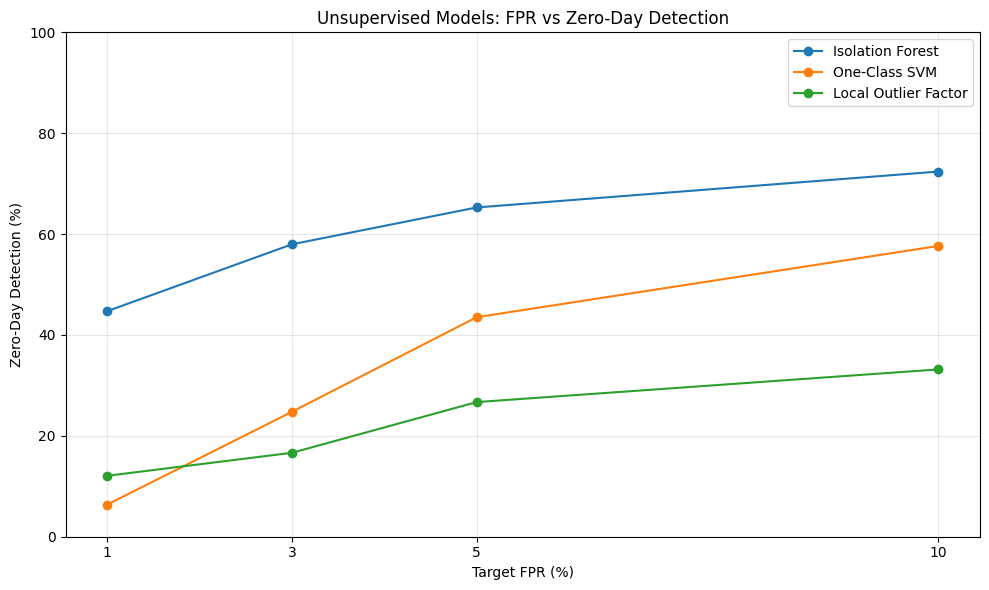

In [9]:
plt.figure(figsize=(10, 6))

for model in unsupervised_operating_points["Model"].unique():
    data = unsupervised_operating_points[
        unsupervised_operating_points["Model"] == model
    ]

    plt.plot(
        data["Target FPR (%)"],
        data["Zero-Day Detection (%)"],
        marker="o",
        label=model
    )

plt.xlabel("Target FPR (%)")
plt.ylabel("Zero-Day Detection (%)")
plt.title("Unsupervised Models: FPR vs Zero-Day Detection")

plt.xticks([1, 3, 5, 10])
plt.ylim(0, 100)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
best_supervised = supervised_comparison.iloc[0]

best_unsupervised = unsupervised_final.iloc[0]

family_comparison = pd.DataFrame({
    "Family": [
        "Supervised",
        "Unsupervised"
    ],
    "Best Model": [
        best_supervised["Model"],
        best_unsupervised["Model"]
    ],
    "Zero-Day Detection (%)": [
        best_supervised["Zero-Day Detection (%)"],
        best_unsupervised["Zero-Day Detection (%)"]
    ]
})

family_comparison

,Family,Best Model,Zero-Day Detection (%)
0,Supervised,Random Forest,56.91
1,Unsupervised,Isolation Forest,65.28


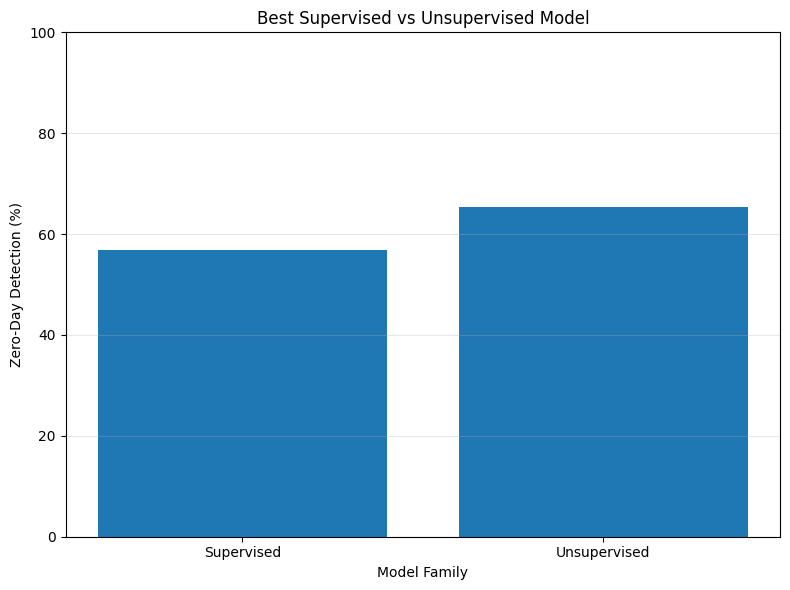

In [11]:
plt.figure(figsize=(8, 6))

plt.bar(
    family_comparison["Family"],
    family_comparison["Zero-Day Detection (%)"]
)

plt.xlabel("Model Family")
plt.ylabel("Zero-Day Detection (%)")
plt.title("Best Supervised vs Unsupervised Model")

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
import os

os.makedirs("../results", exist_ok=True)

supervised_results.to_csv(
    "../results/supervised_results.csv",
    index=False
)

unsupervised_operating_points.to_csv(
    "../results/unsupervised_operating_points.csv",
    index=False
)

unsupervised_final.to_csv(
    "../results/unsupervised_results.csv",
    index=False
)

final_comparison.to_csv(
    "../results/final_comparison.csv",
    index=False
)

family_comparison.to_csv(
    "../results/family_comparison.csv",
    index=False
)

print("All results saved successfully.")

All results saved successfully.
